# NY Hospital Inpatient Discharges - Respiratory Cancer Total Charge Prediction

**Data source:** Hospital Inpatient Discharges (SPARCS De-Identified), 2018-2021  
**Objective:** Predict Total Charges for respiratory cancer inpatient discharges using XGBRegressor  
**Target variable:** Total Charges (continuous, USD)

---

## Table of Contents

1. [Introduction and Business Objectives](#1-introduction-and-business-objectives)
2. [Data Loading and Configuration](#2-data-loading-and-configuration)
3. [Data Preparation and Transformation](#3-data-preparation-and-transformation)
4. [Feature Engineering](#4-feature-engineering)
5. [Modeling with XGBRegressor](#5-modeling-with-xgbregressor)
6. [Unseen Data Prediction](#6-unseen-data-prediction)
7. [Out-of-Pocket Cost Estimation](#7-out-of-pocket-cost-estimation)
8. [Model Export](#8-model-export)

## 1. Introduction and Business Objectives

This notebook builds a regression model to estimate the **Total Charges** for hospital inpatient discharges related to respiratory cancer in New York State.

**Data Sources**
- [Hospital Inpatient Discharges (SPARCS De-Identified)](https://health.data.ny.gov/browse?q=Hospital%20Inpatient%20Discharges%20(SPARCS%20De-Identified)&sortBy=relevance)
- [Data Access - SPARCS](https://www.health.ny.gov/statistics/sparcs/access/)
- Data Dictionary: `sparcs_data_dictionary.xlsx` (in use for all extracts from October 1, 2017 onward)
- [Hospital Inpatient Discharges (SPARCS De-Identified): 2021](https://health.data.ny.gov/Health/Hospital-Inpatient-Discharges-SPARCS-De-Identified/tg3i-cinn)

**Costing Methodology**  
Estimates of inpatient costs were calculated using SPARCS discharge data and Institutional Cost Report (ICR) data. ICRs include Ratios of Cost to Charges (RCCs), which are facility-specific, certified, and subject to audit. For CY 2021, estimated total cost for discharges was calculated using facility-specific 2019 audited RCCs.

**Business Objectives**
- Provide charge estimates to support hospital cost planning.
- Enable out-of-pocket cost estimation for patients with insurance or self-pay.
- Deliver a configurable prediction pipeline deployable via Streamlit.

### Data Dictionary

| Column | Description | Type |
|--------|-------------|------|
| CCSR Procedure Description | Clinical Classifications Software Refined procedure category | Categorical (175 categories) |
| Discharge Year | Calendar year of patient discharge | Integer (2018-2021) |
| Age Group | Patient age bracket | Ordinal (0-17, 18-29, 30-49, 50-69, 70+) |
| Length of Stay | Number of days of inpatient stay (120+ capped at 121) | Numeric |
| Type of Admission | How the patient was admitted | Categorical (Elective, Emergency, Newborn, Trauma, Urgent) |
| Patient Disposition | Discharge destination | Categorical (19 categories) |
| APR DRG Description | All Patient Refined Diagnosis Related Group | Categorical (24 categories) |
| APR Severity of Illness Description | Severity classification | Ordinal (Minor, Moderate, Major, Extreme) |
| APR Medical Surgical Description | Whether the principal treatment was Medical or Surgical | Binary |
| Payment Typology 1 | Primary payer type | Categorical (10 categories) |
| Total Charges | Hospital-specific charges in USD (TARGET) | Continuous |
| Permanent Facility Id | Unique identifier for the hospital facility | Numeric |

## 2. Data Loading and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import (
    load_data,
    apply_mappings,
    impute_facility_id,
    impute_ccsr_procedure,
    apply_ohe,
    split_by_year,
    SELECTED_COLUMNS,
)
from model import (
    build_model,
    train_model,
    predict,
    evaluate,
    predict_single,
    DEFAULT_INFLATION_FACTOR,
)
from out_of_pocket_cost import calculate_insurance_oop, calculate_self_pay

pd.set_option('display.max_columns', None)

In [2]:
DATA_PATH = '2018_2021.csv'
VALIDATION_YEAR = 2021

df = load_data(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (35620, 12)


,CCSR Procedure Description,Discharge Year,Age Group,Length of Stay,Type of Admission,Patient Disposition,APR DRG Description,APR Severity of Illness Description,APR Medical Surgical Description,Payment Typology 1,Total Charges,Permanent Facility Id
0,"LUNG, PLEURA, OR DIAPHRAGM RESECTION (OPEN AND...",2018,70 or Older,4,Elective,Home or Self Care,MAJOR RESPIRATORY & CHEST PROCEDURES,Moderate,Surgical,Medicare,92851.10,1630.0
1,RELEASE OF LUNG AND PLEURA,2018,70 or Older,1,Elective,Home or Self Care,OTHER RESPIRATORY & CHEST PROCEDURES,Minor,Surgical,Private Health Insurance,34994.93,1630.0
2,LYMPH NODE BIOPSY,2018,70 or Older,8,Emergency,Home w/ Home Health Services,NONEXTENSIVE PROCEDURE UNRELATED TO PRINCIPAL ...,Extreme,Surgical,Medicare,53256.78,829.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35620 entries, 0 to 35619
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CCSR Procedure Description           31319 non-null  object 
 1   Discharge Year                       35620 non-null  int64  
 2   Age Group                            35620 non-null  object 
 3   Length of Stay                       35620 non-null  object 
 4   Type of Admission                    35620 non-null  object 
 5   Patient Disposition                  35620 non-null  object 
 6   APR DRG Description                  35620 non-null  object 
 7   APR Severity of Illness Description  35620 non-null  object 
 8   APR Medical Surgical Description     35620 non-null  object 
 9   Payment Typology 1                   35620 non-null  object 
 10  Total Charges                        35620 non-null  float64
 11  Permanent Facility Id       

## 3. Data Preparation and Transformation

This section applies ordinal encoding to categorical features and handles missing values.

**Transformations applied:**
- Length of Stay: '120 +' sentinel replaced with 121, cast to float.
- All categorical columns mapped to integer codes via predefined dictionaries.

**Missing value strategy:**
- CCSR Procedure Description (~4301 NaN): considered MCAR. Imputed using XGBClassifier.
- Permanent Facility Id (8 NaN): considered MNAR (redacted for confidentiality). Imputed using XGBClassifier.

### 3.1 Categorical Mapping

In [4]:
df_mapped = apply_mappings(df)
print("Missing values after mapping:")
print(df_mapped.isna().sum().sort_values(ascending=False))

Missing values after mapping:
CCSR Procedure Description             4301
Permanent Facility Id                     8
Discharge Year                            0
Age Group                                 0
Length of Stay                            0
Type of Admission                         0
Patient Disposition                       0
APR DRG Description                       0
APR Severity of Illness Description       0
APR Medical Surgical Description          0
Payment Typology 1                        0
Total Charges                             0
dtype: int64


### 3.2 Missing Value Imputation - Permanent Facility Id

8 records have Permanent Facility Id redacted for confidentiality (MNAR).  
An XGBClassifier is trained on all other features to predict the facility.

In [5]:
df_imputed = impute_facility_id(df_mapped)
print(f"Permanent Facility Id NaN count: {df_imputed['Permanent Facility Id'].isna().sum()}")

Permanent Facility Id NaN count: 0


### 3.3 Missing Value Imputation - CCSR Procedure Description

~4301 records have missing CCSR Procedure Description, considered MCAR.  
An XGBClassifier is trained on the remaining features to predict the procedure category.

In [6]:
df_imputed = impute_ccsr_procedure(df_imputed)
print("Missing values after all imputation:")
print(df_imputed.isna().sum().sort_values(ascending=False))

Missing values after all imputation:
CCSR Procedure Description             0
Discharge Year                         0
Age Group                              0
Length of Stay                         0
Type of Admission                      0
Patient Disposition                    0
APR DRG Description                    0
APR Severity of Illness Description    0
APR Medical Surgical Description       0
Payment Typology 1                     0
Total Charges                          0
Permanent Facility Id                  0
dtype: int64


## 4. Feature Engineering

**One-Hot Encoding** is applied to nominal categorical features:
- Age Group (5 categories)
- Type of Admission (6 categories, not all present in data)
- Patient Disposition (19 categories)
- APR Medical Surgical Description (2 categories)
- Payment Typology 1 (10 categories)

Ordinal features (APR Severity, APR DRG, CCSR Procedure) and numeric features (Length of Stay, Permanent Facility Id) are passed through without additional encoding.

In [7]:
df_encoded, ohe_transformer = apply_ohe(df_imputed)
print(f"Encoded dataset shape: {df_encoded.shape}")
df_encoded.head(3)

Encoded dataset shape: (35586, 47)


,remainder__Discharge Year,OHE__Age Group_1,OHE__Age Group_2,OHE__Age Group_3,OHE__Age Group_4,OHE__Age Group_5,OHE__Type of Admission_1,OHE__Type of Admission_2,OHE__Type of Admission_4,OHE__Type of Admission_5,OHE__Type of Admission_6,OHE__Patient Disposition_1,OHE__Patient Disposition_2,OHE__Patient Disposition_3,OHE__Patient Disposition_4,OHE__Patient Disposition_5,OHE__Patient Disposition_6,OHE__Patient Disposition_7,OHE__Patient Disposition_8,OHE__Patient Disposition_9,OHE__Patient Disposition_10,OHE__Patient Disposition_11,OHE__Patient Disposition_12,OHE__Patient Disposition_13,OHE__Patient Disposition_14,OHE__Patient Disposition_15,OHE__Patient Disposition_16,OHE__Patient Disposition_17,OHE__Patient Disposition_18,OHE__Patient Disposition_19,OHE__APR Medical Surgical Description_1,OHE__APR Medical Surgical Description_2,OHE__Payment Typology 1_1,OHE__Payment Typology 1_2,OHE__Payment Typology 1_3,OHE__Payment Typology 1_4,OHE__Payment Typology 1_5,OHE__Payment Typology 1_6,OHE__Payment Typology 1_7,OHE__Payment Typology 1_8,OHE__Payment Typology 1_9,remainder__CCSR Procedure Description,remainder__Length of Stay,remainder__APR DRG Description,remainder__APR Severity of Illness Description,remainder__Permanent Facility Id,remainder__Total Charges
0,2018.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,104.0,4.0,8.0,2.0,1630.0,92851.10
1,2018.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,146.0,1.0,14.0,1.0,1630.0,34994.93
2,2018.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105.0,8.0,13.0,4.0,829.0,53256.78


### 4.1 Train / Validation Split

The data is split temporally:  
- Training: 2018-2020  
- Validation: 2021  

This simulates a forward-looking prediction scenario.

In [8]:
X_train, X_valid, y_train, y_valid = split_by_year(df_encoded, VALIDATION_YEAR)

print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}  |  y_valid shape: {y_valid.shape}")

X_train shape: (27158, 45)  |  y_train shape: (27158, 1)
X_valid shape: (8428, 45)  |  y_valid shape: (8428, 1)


## 5. Modeling with XGBRegressor

**Model specification:**
- Algorithm: XGBRegressor (gradient-boosted trees)
- Hyperparameters: 1000 estimators, max depth 4, learning rate 0.1
- Target transformation: log(Total Charges + 3000) to reduce right skew
- Prediction adjustment: inverse log transform + 7.17% inflation factor (IP HCC 2021 Annual Change)

### 5.1 Training

In [9]:
mdl = build_model(n_estimators=1000, max_depth=4, learning_rate=0.1)
mdl = train_model(mdl, X_train, y_train)
print("Model training complete.")

Model training complete.


### 5.2 Validation Predictions and Metrics

In [10]:
preds = predict(mdl, X_valid, inflation_factor=DEFAULT_INFLATION_FACTOR)

metrics = evaluate(y_valid, preds)
for name, value in metrics.items():
    print(f"{name:6s}: {value:.6f}")

R2    : 0.834367
MSE   : 2218675308.538460
MAE   : 21202.782420
MAPE  : 0.202811


### 5.3 Predictions vs Actuals

In [11]:
df_preds = y_valid.copy()
df_preds['Predictions'] = preds

df_preds.describe().apply(lambda s: s.apply('{0:.2f}'.format))

,remainder__Total Charges,Predictions
count,8428.00,8428.00
mean,107212.85,95822.22
std,115744.27,95680.28
min,1754.44,1232.41
25%,46588.99,45107.80
50%,80313.52,73342.52
75%,131298.74,116215.49
max,3532521.32,2126270.25


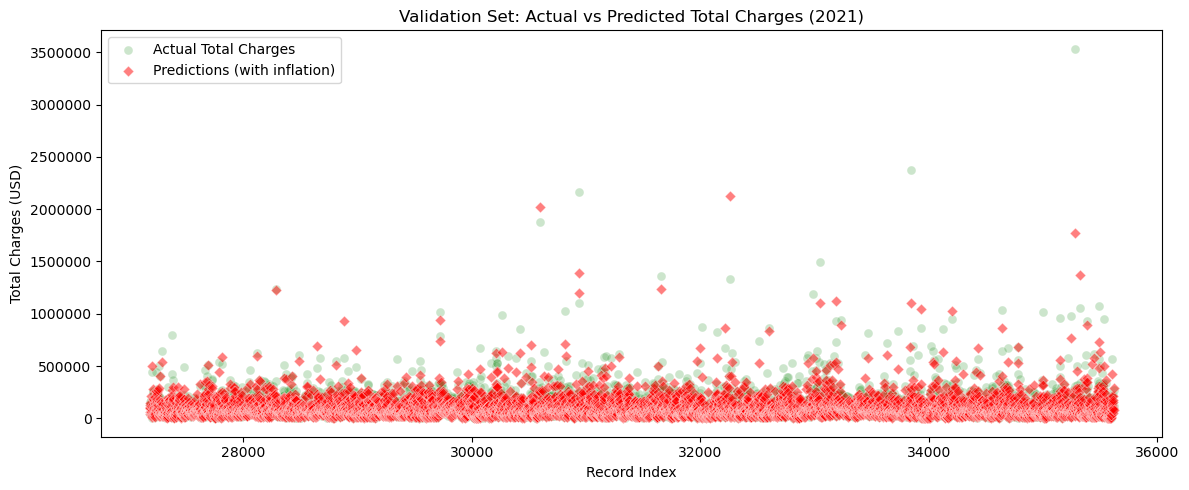

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(
    data=df_preds, y='remainder__Total Charges', x=df_preds.index,
    color='g', marker='o', s=40, alpha=0.2, label='Actual Total Charges', ax=ax
)
sns.scatterplot(
    data=df_preds, y='Predictions', x=df_preds.index,
    color='r', marker='D', s=30, alpha=0.5, label='Predictions (with inflation)', ax=ax
)

ax.ticklabel_format(style='plain', axis='y')
ax.set_ylabel('Total Charges (USD)')
ax.set_xlabel('Record Index')
ax.set_title('Validation Set: Actual vs Predicted Total Charges (2021)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Unseen Data Prediction

Demonstration of predicting Total Charges for a new observation using the trained model. The `predict_single` function accepts raw string labels and handles mapping and OHE internally.

In [13]:
# Example: St Barnabas Hospital (Facility Id 1176)
sample_input = {
    'CCSR Procedure Description': 'MEDIASTINAL PROCEDURES, NEC',
    'Length of Stay': 30,
    'Discharge Year': 2021,
    'Age Group': '50 to 69',
    'Type of Admission': 'Emergency',
    'Patient Disposition': 'Home or Self Care',
    'APR DRG Description': 'RESPIRATORY MALIGNANCY',
    'APR Severity of Illness Description': 'Moderate',
    'APR Medical Surgical Description': 'Medical',
    'Payment Typology 1': 'Medicare',
    'Permanent Facility Id': 1176,
}

estimated_charge = predict_single(mdl, ohe_transformer, sample_input)
print(f"Estimated Total Charge: ${estimated_charge:,.2f}")

Estimated Total Charge: $177,522.77


## 7. Out-of-Pocket Cost Estimation

Two payment scenarios:
- **Health Insurance**: the patient pays the deductible, then co-insurance on the remainder, capped at the out-of-pocket maximum.
- **Self-Pay**: the patient pays the full charge minus any facility/nonprofit discount.

In [14]:
# Health Insurance example
oop_insurance = calculate_insurance_oop(
    estimated_charge=estimated_charge,
    deductible=1500.0,
    co_insurance_pct=20.0,
    oop_max=8000.0,
)
print(f"Insurance - Out-of-Pocket Cost: ${oop_insurance:,.2f}")

# Self-Pay example (25% facility discount)
oop_selfpay = calculate_self_pay(
    estimated_charge=estimated_charge,
    discount_pct=25.0,
)
print(f"Self-Pay  - Out-of-Pocket Cost: ${oop_selfpay:,.2f}")

Insurance - Out-of-Pocket Cost: $8,000.00
Self-Pay  - Out-of-Pocket Cost: $133,142.07


## 8. Model Export

Uncomment the cells below to export the trained model for use in the Streamlit application or other deployment targets.

In [ ]:
# import pickle
# pickle.dump(mdl, open('model.pkl', 'wb'))

# import joblib
# joblib.dump(mdl, open('model_joblib.pkl', 'wb'))